# Synthetic ground truth — why explanation shift can mislead

**The conceptual foundation of the project.** On real data we never know the "true" reason a
model's accuracy moves. So we build a *controlled* synthetic world where we **write the
data-generating rule ourselves**, and can therefore separate two kinds of change:

- **Covariate shift** — the inputs move, but the rule (feature → label) is unchanged. The
  *correct* explanation should **not** change. Any observed explanation shift here is **spurious**
  (a false alarm), and accuracy need not fall.
- **Concept shift** — the rule itself changes. The correct explanation genuinely changes
  (**appropriate** change), and accuracy degrades.

A trustworthy label-free early-warning signal should stay quiet under covariate shift and fire
under concept shift. This notebook shows the SHAP-based signal does the **opposite** — motivating
the pre-registered real-data test (which returned NO-GO). Source: `../../week1_demo.py` Part A.


## Setup — a controlled "credit scoring" world

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold",
                     "axes.grid": True, "grid.alpha": 0.25})

def repo_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "week1_demo.py").exists():
            return base
    raise FileNotFoundError("Run from inside the trustworthy-shift repository.")
ROOT = repo_root(); sys.path.insert(0, str(ROOT))
from week1_demo import shap_importance, explanation_shift   # same metric code as the pipeline

# Named features, each with a KNOWN effect on the label -> the "true reasoning" is explicit.
VARS = ["age", "income_k", "education_yrs", "debt_ratio", "employment_yrs"]
MEAN = np.array([40., 50., 14., 0.35, 8.]); STD = np.array([10., 15., 3., 0.15, 5.])
W_SRC = np.array([0.2, 1.5, 0.8, -1.2, 0.5])     # source rule (income & education help, debt hurts)
W_CON = np.array([0.1, 0.3, 0.4, -2.2, 0.3])     # concept shift: a regime where debt dominates
rng = np.random.default_rng(0)

def make(n, mean, w):
    raw = rng.normal(mean, STD, size=(n, 5))
    z = (raw - MEAN) / STD                         # standardize vs the FIXED source reference
    y = rng.binomial(1, 1 / (1 + np.exp(-(z @ w))))
    return z.astype(np.float32), y

mean_richer = MEAN + np.array([10., 20., 0., 0., 0.])   # covariate shift: older, higher-income
Xtr, ytr = make(6000, MEAN, W_SRC)                      # training distribution
Xid, yid = make(3000, MEAN, W_SRC)                      # in-distribution test
Xcov, ycov = make(3000, mean_richer, W_SRC)             # covariate shift (rule unchanged)
Xcon, ycon = make(3000, MEAN, W_CON)                    # concept shift  (rule changed)
print("synthetic world ready:", dict(zip(VARS, MEAN)))


synthetic world ready: {'age': np.float64(40.0), 'income_k': np.float64(50.0), 'education_yrs': np.float64(14.0), 'debt_ratio': np.float64(0.35), 'employment_yrs': np.float64(8.0)}


## Measure observable vs true explanation change

For each model we compute, under each shift:
- **accuracy drop** (needs labels — the thing we ultimately care about),
- **observable** explanation shift — what a label-free monitor sees: the *same fixed model*'s SHAP
  profile on source vs shifted inputs (fixed background),
- **true** explanation change — an oracle retrained on the shifted data; this is whether the
  *correct* reasoning actually changed.

In [2]:
def models():
    m = {"logreg": LogisticRegression(max_iter=1000),
         "rf": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=0, n_jobs=-1)}
    try:
        from xgboost import XGBClassifier
        m["xgb"] = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 subsample=0.8, eval_metric="logloss", random_state=0)
    except Exception:
        pass
    return m

rows = []
for name, model in models().items():
    model.fit(Xtr, ytr)
    bg = Xtr[:200]                                  # FIXED SHAP background
    imp_src = shap_importance(model, bg, Xid[:300])
    acc_id = accuracy_score(yid, model.predict(Xid))
    for tag, Xt, yt in [("covariate", Xcov, ycov), ("concept", Xcon, ycon)]:
        acc_drop = acc_id - accuracy_score(yt, model.predict(Xt))
        expl_obs = explanation_shift(imp_src, shap_importance(model, bg, Xt[:300]))   # label-free
        oracle = clone(model).fit(Xt, yt)                                            # ground truth
        expl_true = explanation_shift(imp_src, shap_importance(oracle, Xt[:200], Xt[:300]))
        rows.append(dict(model=name, shift=tag, acc_drop=acc_drop,
                         observable=expl_obs, true=expl_true))
import pandas as pd
tab = pd.DataFrame(rows)
tab.round(3)


/Users/feliciasword/Documents/trustworthy-shift/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model,shift,acc_drop,observable,true
0,logreg,covariate,-0.061,0.172,0.040
1,logreg,concept,0.110,0.024,0.386
2,rf,covariate,-0.065,0.141,0.040
3,rf,concept,0.106,0.017,0.433
4,xgb,covariate,-0.061,0.156,0.044
5,xgb,concept,0.100,0.023,0.331


## Figure 4 — appropriate vs spurious explanation change

Averaged over the three models. The dissociation is the whole point:
- **Covariate shift:** the observable signal is **large** but the true change is **small** and
  accuracy barely moves → a **spurious false alarm**.
- **Concept shift:** the observable signal is **small** but the true change is **large** and
  accuracy **craters** → the **dangerous blind spot**.

wrote /Users/feliciasword/Documents/trustworthy-shift/results/figures/fig4_appropriate_vs_spurious.png


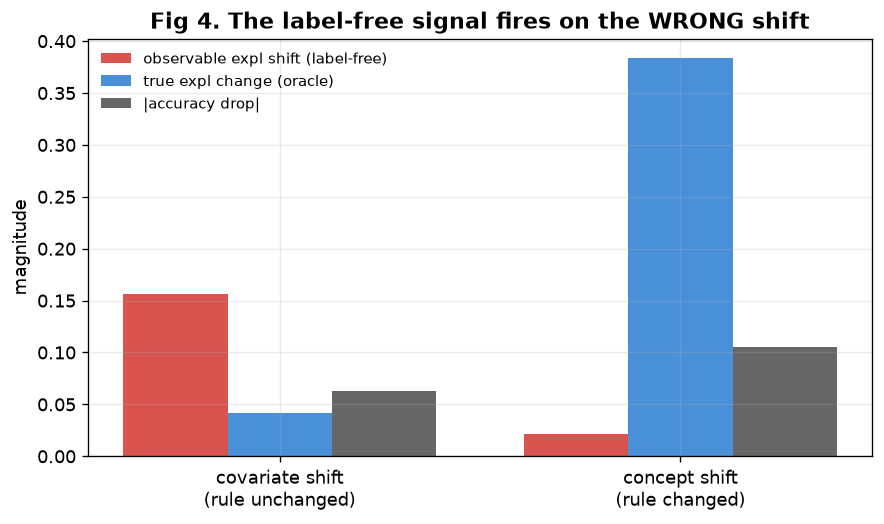

In [3]:
agg = tab.groupby("shift")[["observable", "true", "acc_drop"]].mean().reindex(["covariate", "concept"])
agg["|acc_drop|"] = agg["acc_drop"].abs()

x = np.arange(2); w = 0.26
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x - w, agg["observable"], w, label="observable expl shift (label-free)", color="#d9534f")
ax.bar(x,     agg["true"],       w, label="true expl change (oracle)",          color="#4a90d9")
ax.bar(x + w, agg["|acc_drop|"], w, label="|accuracy drop|",                    color="#666666")
ax.set_xticks(x); ax.set_xticklabels(["covariate shift\n(rule unchanged)", "concept shift\n(rule changed)"])
ax.set_ylabel("magnitude")
ax.set_title("Fig 4. The label-free signal fires on the WRONG shift")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG / "fig4_appropriate_vs_spurious.png", dpi=200, bbox_inches="tight")
print("wrote", FIG / "fig4_appropriate_vs_spurious.png")
plt.show()


**Why this matters.** On covariate shift the observable signal is loud but harmless; on
concept shift — the shift that actually destroys accuracy — a fixed model's observable signal is
quiet. The label-free explanation-shift monitor therefore warns at the wrong times. This synthetic
ground truth predicted exactly what the powered real-data test then confirmed: a pre-registered
**NO-GO** (`01_early_warning_test.ipynb`). It also shows the metric *itself* is sound — it
faithfully tracks the oracle's true change; the problem is that a deployed (fixed) model cannot
see concept shift without labels.

---
Pipeline: [`../../week1_demo.py`](../../week1_demo.py) (Part A) ·
Real-data test: [`01_early_warning_test.ipynb`](01_early_warning_test.ipynb)
